## LangGraph Open Deep Research - Supervisor-Researcher Architecture

In this notebook, we'll explore the **supervisor-researcher delegation architecture** for conducting deep research with LangGraph.

You can visit this repository to see the original application: [Open Deep Research](https://github.com/langchain-ai/open_deep_research)

Let's jump in!

## What We're Building

This implementation uses a **hierarchical delegation pattern** where:

1. **User Clarification** - Optionally asks clarifying questions to understand the research scope
2. **Research Brief Generation** - Transforms user messages into a structured research brief
3. **Supervisor** - A lead researcher that analyzes the brief and delegates research tasks
4. **Parallel Researchers** - Multiple sub-agents that conduct focused research simultaneously
5. **Research Compression** - Each researcher synthesizes their findings
6. **Final Report** - All findings are combined into a comprehensive report

![Architecture Diagram](https://private-user-images.githubusercontent.com/181020547/465824799-12a2371b-8be2-4219-9b48-90503eb43c69.png?jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmF3LmdpdGh1YnVzZXJjb250ZW50LmNvbSIsImtleSI6ImtleTUiLCJleHAiOjE3NjAwNDgyMzcsIm5iZiI6MTc2MDA0NzkzNywicGF0aCI6Ii8xODEwMjA1NDcvNDY1ODI0Nzk5LTEyYTIzNzFiLThiZTItNDIxOS05YjQ4LTkwNTAzZWI0M2M2OS5wbmc_WC1BbXotQWxnb3JpdGhtPUFXUzQtSE1BQy1TSEEyNTYmWC1BbXotQ3JlZGVudGlhbD1BS0lBVkNPRFlMU0E1M1BRSzRaQSUyRjIwMjUxMDA5JTJGdXMtZWFzdC0xJTJGczMlMkZhd3M0X3JlcXVlc3QmWC1BbXotRGF0ZT0yMDI1MTAwOVQyMjEyMTdaJlgtQW16LUV4cGlyZXM9MzAwJlgtQW16LVNpZ25hdHVyZT1iYTRmYTAzYjkzYjA2MGE4ZTZlYjQ4ODU1OWIwY2VlZWU0Mzk0YzdmMjQ1YTlhMDMyNmI3NWNlZTQxNDdlZGViJlgtQW16LVNpZ25lZEhlYWRlcnM9aG9zdCJ9.a8477QD1J4Lrmys7jB8gt_H5pdiKBsKsu3npEqZjEpo)

This differs from a section-based approach by allowing dynamic task decomposition based on the research question, rather than predefined sections.

## Dependencies

You'll need API keys for Anthropic (for the LLM) and Tavily (for web search). We'll configure the system to use Anthropic's Claude Sonnet 4 exclusively.

In [22]:
import os
import getpass

os.environ["ANTHROPIC_API_KEY"] = getpass.getpass("Enter your Anthropic API key: ")
os.environ["TAVILY_API_KEY"] = getpass.getpass("Enter your Tavily API key: ")

## Task 1: State Definitions

The state structure is hierarchical with three levels:

### Agent State (Top Level)
Contains the overall conversation messages, research brief, accumulated notes, and final report.

### Supervisor State (Middle Level)
Manages the research supervisor's messages, research iterations, and coordinating parallel researchers.

### Researcher State (Bottom Level)
Each individual researcher has their own message history, tool call iterations, and research findings.

We also have structured outputs for tool calling:
- **ConductResearch** - Tool for supervisor to delegate research to a sub-agent
- **ResearchComplete** - Tool to signal research phase is done
- **ClarifyWithUser** - Structured output for asking clarifying questions
- **ResearchQuestion** - Structured output for the research brief

Let's import these from our library: [`open_deep_library/state.py`](open_deep_library/state.py)

In [23]:
# Import state definitions from the library
from open_deep_library.state import (
    # Main workflow states
    AgentState,           # Lines 65-72: Top-level agent state with messages, research_brief, notes, final_report
    AgentInputState,      # Lines 62-63: Input state is just messages
    
    # Supervisor states
    SupervisorState,      # Lines 74-81: Supervisor manages research delegation and iterations
    
    # Researcher states
    ResearcherState,      # Lines 83-90: Individual researcher with messages and tool iterations
    ResearcherOutputState, # Lines 92-96: Output from researcher (compressed research + raw notes)
    
    # Structured outputs for tool calling
    ConductResearch,      # Lines 15-19: Tool for delegating research to sub-agents
    ResearchComplete,     # Lines 21-22: Tool to signal research completion
    ClarifyWithUser,      # Lines 30-41: Structured output for user clarification
    ResearchQuestion,     # Lines 43-48: Structured output for research brief
)

#### ❓ Question 1:

 Explain the interrelationships between the three states.  Why don't we just make a single huge state?

 #### Answer
 Agent State (Top Level) orchestrates the entire research workflow and contains conversation messages, notes, and final report. It acts as the global coordinator that maintains the big picture.

Supervisor (Middle Level) manages research delegation and iteration control. Contains supervisor messages, research brief, notes, and iterations counter. Acts as the research manager that breaks down tasks and coordinates multiple researchers.

Research State (Bottom Level) handles individual research tasks. Contains researcher messages, tool call iterations, specific research topics, and compressed research. Focuses on executing specific research assignments.

Ther is not a single huge monolithic state because of seperation of concerns. Each state has distinct responsibilities. The hierarchical design enables true parallelization. MultipleResearcherState instances can run simultaneously and the supervisor can manage multiple concurrent research threads. Because of the parallel processing it also allows for good scaling and modularity compared to trying to manage everything in a single massive state object.

## Task 2: Utility Functions and Tools

The system uses several key utilities:

### Search Tools
- **tavily_search** - Async web search with automatic summarization to stay within token limits
- Supports Anthropic native web search and Tavily API

### Reflection Tools
- **think_tool** - Allows researchers to reflect on their progress and plan next steps (ReAct pattern)

### Helper Utilities
- **get_all_tools** - Assembles the complete toolkit (search + MCP + reflection)
- **get_today_str** - Provides current date context for research
- Token limit handling utilities for graceful degradation

These are defined in [`open_deep_library/utils.py`](open_deep_library/utils.py)

In [24]:
# Import utility functions and tools from the library
from open_deep_library.utils import (
    # Search tool - Lines 43-136: Tavily search with automatic summarization
    tavily_search,
    
    # Reflection tool - Lines 219-244: Strategic thinking tool for ReAct pattern
    think_tool,
    
    # Tool assembly - Lines 569-597: Get all configured tools
    get_all_tools,
    
    # Date utility - Lines 872-879: Get formatted current date
    get_today_str,
    
    # Supporting utilities for error handling
    get_api_key_for_model,          # Lines 892-914: Get API keys from config or env
    is_token_limit_exceeded,         # Lines 665-701: Detect token limit errors
    get_model_token_limit,           # Lines 831-846: Look up model's token limit
    remove_up_to_last_ai_message,    # Lines 848-866: Truncate messages for retry
    anthropic_websearch_called,      # Lines 607-637: Detect Anthropic native search usage
    openai_websearch_called,         # Lines 639-658: Detect OpenAI native search usage
    get_notes_from_tool_calls,       # Lines 599-601: Extract notes from tool messages
)

### ❓ Question 2:  

What are the advantages and disadvantages of importing these components instead of including them in the notebook?

### Answers

Advantages of importing from library
Notebook Clarity and Focus and reduced clutter.
Maintainability, sinngle source of truth, bug fixes and improvements happen in one place. Version control, Library code can be versioned and updated independently.
Performance, faster loading library code is already compiled and cached. Memory efficiency shared imports reduce memory footprints. Parallel development, library and notebook can be developed independently.

Disadvantages of importing from library
Reduced transparency, black box effect. Can't immediately see how components work. Requires understanding of multiple files to see the full picture.
Dependency Management, requires proper Python path and import setup.
Cognitive Load, context switching, need to jump between notebook and library files.

Inline approach is better when debugging and troubleshooting is a primary learning objective or when working with prototype or experimental code. Import approach is better when working with production-ready code that's well tested.


## Task 3: Configuration System

The configuration system controls:

### Research Behavior
- **allow_clarification** - Whether to ask clarifying questions before research
- **max_concurrent_research_units** - How many parallel researchers can run (default: 5)
- **max_researcher_iterations** - How many times supervisor can delegate research (default: 6)
- **max_react_tool_calls** - Tool call limit per researcher (default: 10)

### Model Configuration
- **research_model** - Model for research and supervision (we'll use Anthropic)
- **compression_model** - Model for synthesizing findings
- **final_report_model** - Model for writing the final report
- **summarization_model** - Model for summarizing web search results

### Search Configuration
- **search_api** - Which search API to use (ANTHROPIC, TAVILY, or NONE)
- **max_content_length** - Character limit before summarization

Defined in [`open_deep_library/configuration.py`](open_deep_library/configuration.py)

In [25]:
# Import configuration from the library
from open_deep_library.configuration import (
    Configuration,    # Lines 38-247: Main configuration class with all settings
    SearchAPI,        # Lines 11-17: Enum for search API options (ANTHROPIC, TAVILY, NONE)
)

## Task 4: Prompt Templates

The system uses carefully engineered prompts for each phase:

### Phase 1: Clarification
**clarify_with_user_instructions** - Analyzes if the research scope is clear or needs clarification

### Phase 2: Research Brief
**transform_messages_into_research_topic_prompt** - Converts user messages into a detailed research brief

### Phase 3: Supervisor
**lead_researcher_prompt** - System prompt for the supervisor that manages delegation strategy

### Phase 4: Researcher
**research_system_prompt** - System prompt for individual researchers conducting focused research

### Phase 5: Compression
**compress_research_system_prompt** - Prompt for synthesizing research findings without losing information

### Phase 6: Final Report
**final_report_generation_prompt** - Comprehensive prompt for writing the final report

All prompts are defined in [`open_deep_library/prompts.py`](open_deep_library/prompts.py)

In [26]:
# Import prompt templates from the library
from open_deep_library.prompts import (
    clarify_with_user_instructions,                    # Lines 3-41: Ask clarifying questions
    transform_messages_into_research_topic_prompt,     # Lines 44-77: Generate research brief
    lead_researcher_prompt,                            # Lines 79-136: Supervisor system prompt
    research_system_prompt,                            # Lines 138-183: Researcher system prompt
    compress_research_system_prompt,                   # Lines 186-222: Research compression prompt
    final_report_generation_prompt,                    # Lines 228-308: Final report generation
)

## Task 5: Node Functions - The Building Blocks

Now let's look at the node functions that make up our graph. We'll import them from the library and understand what each does.

### The Complete Research Workflow

The workflow consists of 8 key nodes organized into 3 subgraphs:

1. **Main Graph Nodes:**
   - `clarify_with_user` - Entry point that checks if clarification is needed
   - `write_research_brief` - Transforms user input into structured research brief
   - `final_report_generation` - Synthesizes all research into final report

2. **Supervisor Subgraph Nodes:**
   - `supervisor` - Lead researcher that plans and delegates
   - `supervisor_tools` - Executes supervisor's tool calls (delegation, reflection)

3. **Researcher Subgraph Nodes:**
   - `researcher` - Individual researcher conducting focused research
   - `researcher_tools` - Executes researcher's tool calls (search, reflection)
   - `compress_research` - Synthesizes researcher's findings

All nodes are defined in [`open_deep_library/deep_researcher.py`](open_deep_library/deep_researcher.py)

### Node 1: clarify_with_user

**Purpose:** Analyzes user messages and asks clarifying questions if the research scope is unclear.

**Key Steps:**
1. Check if clarification is enabled in configuration
2. Use structured output to analyze if clarification is needed
3. If needed, end with a clarifying question for the user
4. If not needed, proceed to research brief with verification message

**Implementation:** [`open_deep_library/deep_researcher.py` lines 60-115](open_deep_library/deep_researcher.py#L60-L115)

In [27]:
# Import the clarify_with_user node
from open_deep_library.deep_researcher import clarify_with_user

### Node 2: write_research_brief

**Purpose:** Transforms user messages into a structured research brief for the supervisor.

**Key Steps:**
1. Use structured output to generate detailed research brief from messages
2. Initialize supervisor with system prompt and research brief
3. Set up supervisor messages with proper context

**Why this matters:** A well-structured research brief helps the supervisor make better delegation decisions.

**Implementation:** [`open_deep_library/deep_researcher.py` lines 118-175](open_deep_library/deep_researcher.py#L118-L175)

In [28]:
# Import the write_research_brief node
from open_deep_library.deep_researcher import write_research_brief

### Node 3: supervisor

**Purpose:** Lead research supervisor that plans research strategy and delegates to sub-researchers.

**Key Steps:**
1. Configure model with three tools:
   - `ConductResearch` - Delegate research to a sub-agent
   - `ResearchComplete` - Signal that research is done
   - `think_tool` - Strategic reflection before decisions
2. Generate response based on current context
3. Increment research iteration count
4. Proceed to tool execution

**Decision Making:** The supervisor uses `think_tool` to reflect before delegating research, ensuring thoughtful decomposition of the research question.

**Implementation:** [`open_deep_library/deep_researcher.py` lines 178-223](open_deep_library/deep_researcher.py#L178-L223)

In [29]:
# Import the supervisor node (from supervisor subgraph)
from open_deep_library.deep_researcher import supervisor

### Node 4: supervisor_tools

**Purpose:** Executes the supervisor's tool calls, including strategic thinking and research delegation.

**Key Steps:**
1. Check exit conditions:
   - Exceeded maximum iterations
   - No tool calls made
   - `ResearchComplete` called
2. Process `think_tool` calls for strategic reflection
3. Execute `ConductResearch` calls in parallel:
   - Spawn researcher subgraphs for each delegation
   - Limit to `max_concurrent_research_units` (default: 5)
   - Gather all results asynchronously
4. Aggregate findings and return to supervisor

**Parallel Execution:** This is where the magic happens - multiple researchers work simultaneously on different aspects of the research question.

**Implementation:** [`open_deep_library/deep_researcher.py` lines 225-349](open_deep_library/deep_researcher.py#L225-L349)

In [30]:
# Import the supervisor_tools node
from open_deep_library.deep_researcher import supervisor_tools

### Node 5: researcher

**Purpose:** Individual researcher that conducts focused research on a specific topic.

**Key Steps:**
1. Load all available tools (search, MCP, reflection)
2. Configure model with tools and researcher system prompt
3. Generate response with tool calls
4. Increment tool call iteration count

**ReAct Pattern:** Researchers use `think_tool` to reflect after each search, deciding whether to continue or provide their answer.

**Available Tools:**
- Search tools (Tavily or Anthropic native search)
- `think_tool` for strategic reflection
- `ResearchComplete` to signal completion
- MCP tools (if configured)

**Implementation:** [`open_deep_library/deep_researcher.py` lines 365-424](open_deep_library/deep_researcher.py#L365-L424)

In [31]:
# Import the researcher node (from researcher subgraph)
from open_deep_library.deep_researcher import researcher

### Node 6: researcher_tools

**Purpose:** Executes the researcher's tool calls, including searches and strategic reflection.

**Key Steps:**
1. Check early exit conditions (no tool calls, native search used)
2. Execute all tool calls in parallel:
   - Search tools fetch and summarize web content
   - `think_tool` records strategic reflections
   - MCP tools execute external integrations
3. Check late exit conditions:
   - Exceeded `max_react_tool_calls` (default: 10)
   - `ResearchComplete` called
4. Continue research loop or proceed to compression

**Error Handling:** Safely handles tool execution errors and continues with available results.

**Implementation:** [`open_deep_library/deep_researcher.py` lines 435-509](open_deep_library/deep_researcher.py#L435-L509)

In [32]:
# Import the researcher_tools node
from open_deep_library.deep_researcher import researcher_tools

### Node 7: compress_research

**Purpose:** Compresses and synthesizes research findings into a concise, structured summary.

**Key Steps:**
1. Configure compression model
2. Add compression instruction to messages
3. Attempt compression with retry logic:
   - If token limit exceeded, remove older messages
   - Retry up to 3 times
4. Extract raw notes from tool and AI messages
5. Return compressed research and raw notes

**Why Compression?** Researchers may accumulate lots of tool outputs and reflections. Compression ensures:
- All important information is preserved
- Redundant information is deduplicated
- Content stays within token limits for the final report

**Token Limit Handling:** Gracefully handles token limit errors by progressively truncating messages.

**Implementation:** [`open_deep_library/deep_researcher.py` lines 511-585](open_deep_library/deep_researcher.py#L511-L585)

In [33]:
# Import the compress_research node
from open_deep_library.deep_researcher import compress_research

### Node 8: final_report_generation

**Purpose:** Generates the final comprehensive research report from all collected findings.

**Key Steps:**
1. Extract all notes from completed research
2. Configure final report model
3. Attempt report generation with retry logic:
   - If token limit exceeded, truncate findings by 10%
   - Retry up to 3 times
4. Return final report or error message

**Token Limit Strategy:**
- First retry: Use model's token limit × 4 as character limit
- Subsequent retries: Reduce by 10% each time
- Graceful degradation with helpful error messages

**Report Quality:** The prompt guides the model to create well-structured reports with:
- Proper headings and sections
- Inline citations
- Comprehensive coverage of all findings
- Sources section at the end

**Implementation:** [`open_deep_library/deep_researcher.py` lines 607-697](open_deep_library/deep_researcher.py#L607-L697)

In [35]:
# Import the final_report_generation node
from open_deep_library.deep_researcher import final_report_generation

## Task 6: Graph Construction - Putting It All Together

The system is organized into three interconnected graphs:

### 1. Researcher Subgraph (Bottom Level)
Handles individual focused research on a specific topic:
```
START → researcher → researcher_tools → compress_research → END
               ↑            ↓
               └────────────┘ (loops until max iterations or ResearchComplete)
```

### 2. Supervisor Subgraph (Middle Level)
Manages research delegation and coordination:
```
START → supervisor → supervisor_tools → END
            ↑              ↓
            └──────────────┘ (loops until max iterations or ResearchComplete)
            
supervisor_tools spawns multiple researcher_subgraphs in parallel
```

### 3. Main Deep Researcher Graph (Top Level)
Orchestrates the complete research workflow:
```
START → clarify_with_user → write_research_brief → research_supervisor → final_report_generation → END
                 ↓                                       (supervisor_subgraph)
               (may end early if clarification needed)
```

Let's import the compiled graphs from the library.

In [36]:
# Import the pre-compiled graphs from the library
from open_deep_library.deep_researcher import (
    # Bottom level: Individual researcher workflow
    researcher_subgraph,    # Lines 588-605: researcher → researcher_tools → compress_research
    
    # Middle level: Supervisor coordination
    supervisor_subgraph,    # Lines 351-363: supervisor → supervisor_tools (spawns researchers)
    
    # Top level: Complete research workflow
    deep_researcher,        # Lines 699-719: Main graph with all phases
)

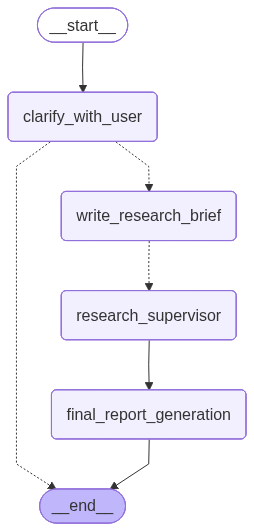

In [37]:
deep_researcher

## Why This Architecture?

### Advantages of Supervisor-Researcher Delegation

1. **Dynamic Task Decomposition**
   - Unlike section-based approaches with predefined structure, the supervisor can break down research based on the actual question
   - Adapts to different types of research (comparisons, lists, deep dives, etc.)

2. **Parallel Execution**
   - Multiple researchers work simultaneously on different aspects
   - Much faster than sequential section processing
   - Configurable parallelism (1-20 concurrent researchers)

3. **ReAct Pattern for Quality**
   - Researchers use `think_tool` to reflect after each search
   - Prevents excessive searching and improves search quality
   - Natural stopping conditions based on information sufficiency

4. **Flexible Tool Integration**
   - Easy to add MCP tools for specialized research
   - Supports multiple search APIs (Anthropic, Tavily)
   - Each researcher can use different tool combinations

5. **Graceful Token Limit Handling**
   - Compression prevents token overflow
   - Progressive truncation in final report generation
   - Research can scale to arbitrary depths

### Trade-offs

- **Complexity:** More moving parts than section-based approach
- **Cost:** Parallel researchers use more tokens (but faster)
- **Unpredictability:** Research structure emerges dynamically

## Task 7: Running the Deep Researcher

Now let's see the system in action! We'll use it to analyze a PDF document about how people use AI.

### Setup

We need to:
1. Load the PDF document
2. Configure the execution with Anthropic settings
3. Run the research workflow

In [38]:
# Load the PDF document
from pathlib import Path
import PyPDF2

def load_pdf(pdf_path: str) -> str:
    """Load and extract text from PDF."""
    pdf_text = ""
    with open(pdf_path, 'rb') as file:
        pdf_reader = PyPDF2.PdfReader(file)
        for page in pdf_reader.pages:
            pdf_text += page.extract_text() + "\n\n"
    return pdf_text

# Load the PDF about how people use AI
pdf_path = "data/howpeopleuseai.pdf"
pdf_content = load_pdf(pdf_path)

print(f"Loaded PDF with {len(pdf_content)} characters")
print(f"First 500 characters:\n{pdf_content[:500]}...")

Loaded PDF with 112460 characters
First 500 characters:
NBER WORKING PAPER SERIES
HOW PEOPLE USE CHATGPT
Aaron Chatterji
Thomas Cunningham
David J. Deming
Zoe Hitzig
Christopher Ong
Carl Yan Shan
Kevin Wadman
Working Paper 34255
http://www.nber.org/papers/w34255
NATIONAL BUREAU OF ECONOMIC RESEARCH
1050 Massachusetts Avenue
Cambridge, MA 02138
September 2025
We acknowledge help and comments from Joshua Achiam, Hemanth Asirvatham, Ryan 
Beiermeister,  Rachel Brown, Cassandra Duchan Solis, Jason Kwon, Elliott Mokski, Kevin Rao, 
Harrison Satcher,  Gawe...


In [39]:
# Set up the graph with Anthropic configuration
from IPython.display import Markdown, display
import uuid

# Note: deep_researcher is already compiled from the library
# For this demo, we'll use it directly without additional checkpointing
graph = deep_researcher

print("✓ Graph ready for execution")
print("  (Note: The graph is pre-compiled from the library)")

✓ Graph ready for execution
  (Note: The graph is pre-compiled from the library)


### Configuration for Anthropic

We'll configure the system to use:
- **Claude Sonnet 4** for all research, supervision, and report generation
- **Tavily** for web search (you can also use Anthropic's native search)
- **Moderate parallelism** (3 concurrent researchers)
- **Clarification enabled** (will ask if research scope is unclear)

In [40]:
# Configure for Anthropic with moderate settings
config = {
    "configurable": {
        # Model configuration - using Claude Sonnet 4 for everything
        "research_model": "anthropic:claude-sonnet-4-20250514",
        "research_model_max_tokens": 10000,
        
        "compression_model": "anthropic:claude-sonnet-4-20250514",
        "compression_model_max_tokens": 8192,
        
        "final_report_model": "anthropic:claude-sonnet-4-20250514",
        "final_report_model_max_tokens": 10000,
        
        "summarization_model": "anthropic:claude-sonnet-4-20250514",
        "summarization_model_max_tokens": 8192,
        
        # Research behavior
        "allow_clarification": True,
        "max_concurrent_research_units": 1,  # 1 parallel researchers
        "max_researcher_iterations": 2,      # Supervisor can delegate up to 2 times
        "max_react_tool_calls": 3,           # Each researcher can make up to 3 tool calls
        
        # Search configuration
        "search_api": "tavily",  # Using Tavily for web search
        "max_content_length": 50000,
        
        # Thread ID for this conversation
        "thread_id": str(uuid.uuid4())
    }
}

print("✓ Configuration ready")
print(f"  - Research Model: Claude Sonnet 4")
print(f"  - Max Concurrent Researchers: 3")
print(f"  - Max Iterations: 4")
print(f"  - Search API: Tavily")

✓ Configuration ready
  - Research Model: Claude Sonnet 4
  - Max Concurrent Researchers: 3
  - Max Iterations: 4
  - Search API: Tavily


### Execute the Research

Now let's run the research! We'll ask the system to analyze the PDF and provide insights about how people use AI.

The workflow will:
1. **Clarify** - Check if the request is clear (may skip if obvious)
2. **Research Brief** - Transform our request into a structured brief
3. **Supervisor** - Plan research strategy and delegate to researchers
4. **Parallel Research** - Multiple researchers gather information simultaneously
5. **Compression** - Each researcher synthesizes their findings
6. **Final Report** - All findings combined into comprehensive report

In [41]:
# Create our research request with PDF context
research_request = f"""
I have a PDF document about how people use AI. Please analyze this document and provide insights about:

1. What are the main findings about how people are using AI?
2. What are the most common use cases?
3. What trends or patterns emerge from the data?

Here's the PDF content:

{pdf_content[:10000]}  # First 10k chars to stay within limits

...[content truncated for context window]
"""

# Execute the graph
async def run_research():
    """Run the research workflow and display results."""
    print("Starting research workflow...\n")
    
    async for event in graph.astream(
        {"messages": [{"role": "user", "content": research_request}]},
        config,
        stream_mode="updates"
    ):
        # Display each step
        for node_name, node_output in event.items():
            print(f"\n{'='*60}")
            print(f"Node: {node_name}")
            print(f"{'='*60}")
            
            if node_name == "clarify_with_user":
                if "messages" in node_output:
                    last_msg = node_output["messages"][-1]
                    print(f"\n{last_msg.content}")
            
            elif node_name == "write_research_brief":
                if "research_brief" in node_output:
                    print(f"\nResearch Brief Generated:")
                    print(f"{node_output['research_brief'][:500]}...")
            
            elif node_name == "supervisor":
                print(f"\nSupervisor planning research strategy...")
                if "supervisor_messages" in node_output:
                    last_msg = node_output["supervisor_messages"][-1]
                    if hasattr(last_msg, 'tool_calls') and last_msg.tool_calls:
                        print(f"Tool calls: {len(last_msg.tool_calls)}")
                        for tc in last_msg.tool_calls:
                            print(f"  - {tc['name']}")
            
            elif node_name == "supervisor_tools":
                print(f"\nExecuting supervisor's tool calls...")
                if "notes" in node_output:
                    print(f"Research notes collected: {len(node_output['notes'])}")
            
            elif node_name == "final_report_generation":
                if "final_report" in node_output:
                    print(f"\n" + "="*60)
                    print("FINAL REPORT GENERATED")
                    print("="*60 + "\n")
                    display(Markdown(node_output["final_report"]))
    
    print("\n" + "="*60)
    print("Research workflow completed!")
    print("="*60)

# Run the research
await run_research()

Starting research workflow...


Node: clarify_with_user

I have sufficient information to analyze the NBER working paper "How People Use ChatGPT" and provide the insights you requested. I understand you want me to focus on:

1. Main findings about how people are using AI (specifically ChatGPT)
2. Most common use cases identified in the research
3. Trends and patterns that emerge from the data

The document provides comprehensive data on ChatGPT usage patterns from November 2022 through July 2025, including growth statistics, demographic breakdowns, work vs. non-work usage, and detailed conversation classifications. I will now analyze this research and provide you with a detailed report covering all three areas you specified.

Node: write_research_brief

Research Brief Generated:
I need a comprehensive analysis of the NBER working paper "How People Use ChatGPT" (Working Paper No. 34255, September 2025) by Aaron Chatterji, Thomas Cunningham, David J. Deming, Zoe Hitzig, Christopher Ong, 


Node: research_supervisor

Node: final_report_generation

FINAL REPORT GENERATED



# Comprehensive Analysis of the NBER Working Paper "How People Use ChatGPT"

## Main Findings About AI Usage Patterns

### Unprecedented Global Adoption and Growth

The NBER working paper reveals that ChatGPT achieved remarkable adoption rates, reaching over 700 million weekly active users by July 2025, representing approximately 10% of the world's adult population.[1][2] This growth trajectory had no precedent for a new technology, with the platform reaching 1 million users by December 5, 2022, and 100 million weekly active users by November 2023.[3] Weekly active users have been doubling every 7-8 months since launch, with users sending over 2.6 billion messages daily by June 2025 (more than 30,000 messages per second) and 18 billion messages weekly by July 2025.[1][4]

To put this growth in perspective, ChatGPT reached 1 billion daily messages in December 2024, accomplishing in under two years what took Google Search eight years to achieve. Google Search, available to the public starting in September 1999, reached 1 billion daily searches eight years later, while ChatGPT achieved this milestone in less than two years.[3]

### Dramatic Shift from Work to Non-Work Usage

One of the most significant findings concerns the evolution of usage patterns between work-related and non-work-related activities. The research shows a substantial shift in usage patterns over time: work-related messages declined from 47% in June 2024 to just 27% in June 2025, while non-work-related messages increased from 53% to more than 70% of all usage during the same period.[2][4][5] This trend represents a fundamental change in how people perceive and utilize AI chatbots, suggesting they have moved beyond being primarily productivity tools to becoming integral parts of daily life.

The decrease in work-related message share is primarily attributed to changing usage patterns within existing user cohorts rather than simply the composition of new users joining the platform. This indicates that as users become more familiar with ChatGPT's capabilities, they increasingly find value in non-work applications.[5]

### Demographic Evolution and Narrowing Gaps

The research documents significant demographic shifts in ChatGPT adoption. Early adopters were disproportionately male, with over 80% of users having typically masculine first names in the first few months after launch. However, this gender gap has narrowed dramatically over time, with 52% of active users having typically female names by July 2025, indicating gender parity has been achieved.[1][2][5]

Age patterns show that nearly half of all messages sent by adults come from users under 26 years old, though age gaps have narrowed in recent months. The data also reveals that older users are more likely to use ChatGPT for work-related purposes.[5] Educational background significantly influences usage patterns, with 37% of messages being work-related for users with less than a bachelor's degree, compared to 46% for users with exactly a bachelor's degree and 48% for those with some graduate education.[5]

### Global Economic Democratization

The study reveals fascinating patterns in global adoption that suggest AI technology is democratizing access across economic boundaries. Usage growth has been fastest in low- and middle-income countries, with countries at the 50th percentile of GDP per capita now showing similar usage rates to those at the 90th percentile. Adoption growth in low- and middle-income countries has been 4× higher than in high-income countries, with Brazil, South Korea, and the United States showing comparable ChatGPT usage rates despite vastly different GDP per capita levels ($10k, $34k, and $86k respectively).[1][2][5]

## Most Common Use Cases Identified

### The Dominant Three Categories

The research identifies three primary categories that collectively account for nearly 80% of all ChatGPT conversations: Practical Guidance, Seeking Information, and Writing.[1][2][4][5] This finding represents one of the most comprehensive categorizations of AI chatbot usage to date.

**Practical Guidance** emerges as the most common use case, representing 29% of all conversations. This category encompasses a broad range of activities including tutoring and teaching, advice on various topics, and creative ideation. Notably, about 10% of all messages are requests for tutoring or teaching, suggesting that education represents a key use case for ChatGPT and highlighting the platform's role in democratizing access to personalized instruction.[4][5]

**Seeking Information** accounts for 24% of conversations and involves factual searches that appear to function as a very close substitute for traditional web search engines. This category includes searching for information about people, current events, products, and recipes, demonstrating ChatGPT's role as an information discovery tool.[4]

**Writing** represents 24% of conversations and includes the automated production of emails, documents, and other communications, as well as editing, critiquing, summarizing, and translating text provided by users. Importantly, about two-thirds of all writing messages ask ChatGPT to modify existing user text rather than create entirely new content from scratch. Writing dominates work-related tasks, accounting for 40% of work-related messages on average in June 2025.[2][4][5]

### User Intent Classification System

The study introduces an innovative classification system that categorizes user intent into three distinct approaches:

**"Asking"** represents 49% of messages and involves seeking information for decision-making, advice, and guidance. This category has grown faster than others and receives higher user satisfaction ratings, suggesting that many users find the most value in using ChatGPT as a decision-support tool.[3][4][5]

**"Doing"** accounts for 40% of messages and encompasses requests for task completion such as writing emails, generating reports, or creating code. In work contexts, "Doing" messages dominate at 56%, with writing tasks comprising 35% of all work-related queries.[2][3][4]

**"Expressing"** comprises 11% of messages and involves social/emotional communication and casual chat. This represents a smaller but significant portion of usage that demonstrates ChatGPT's role beyond purely functional applications.[3][4][5]

### Work-Related Usage Breakdown

The research reveals that work-related usage concentrates around two broad activities that account for 58% of work messages: obtaining, documenting, and interpreting information; and making decisions, giving advice, solving problems, and thinking creatively. These patterns remain consistent across various occupations from management and STEM fields to sales and administration.[3]

### Smaller but Notable Use Cases

The study challenges some assumptions about AI usage by revealing that computer programming accounts for only 4.2% of messages, significantly lower than many expected and contradicting assumptions about AI chatbot usage being primarily technical.[2][3][4][5] Similarly, social/emotional uses represent just 2.4% of conversations, with only 1.9% being about "Relationships and Personal Reflection," indicating that companionship represents a relatively small share of overall usage.[3][4]

## Trends and Patterns from the Data

### Temporal Evolution and User Engagement

The research documents fascinating temporal patterns in user behavior. All user cohorts, regardless of when they signed up, showed similar usage patterns: relatively flat engagement through most of 2024, followed by substantial increases beginning in early 2025. This suggests that ChatGPT became substantially better or more user-friendly during this period.[1]

Early adopters (Q1 2023 signups) were sending 40% more messages per day by July 2025 compared to two years earlier, while Q3-Q4 2024 signups nearly doubled their daily message volume within less than a year. This pattern indicates that users are becoming more engaged over time rather than experiencing typical technology adoption fatigue.[1]

Total message volume increased by 5.8× in the past year alone, while user volume grew by 3.2×, indicating that users are not only joining the platform but also engaging more intensively over time. Message volume has grown faster than user volume, suggesting deepening engagement among existing users.[1][4]

### User Satisfaction and Quality Improvements

User satisfaction remains high and has been improving over time, with positive interactions outnumbering negative ones by a 4:1 ratio. Good interactions were about three times as common as bad interactions at the end of 2024, but good interactions grew much more rapidly over the following nine months. By July 2025, positive interactions were more than four times more common than negative ones.[2][3]

The data shows that "Asking" messages consistently receive higher user satisfaction ratings than "Doing" messages, reinforcing the finding that many users derive the most value from ChatGPT's decision-support capabilities rather than its task-completion functions.[2][3]

### Cohort-Based Usage Evolution

The research reveals interesting cohort-based patterns that challenge typical technology adoption curves. Rather than showing declining engagement over time (as is common with many digital products), ChatGPT users across all cohorts have increased their usage, particularly beginning in early 2025. This suggests continuous improvement in the product's utility and user experience.[1]

The decrease in work-related message share is primarily due to changing usage within existing user cohorts rather than changes in the composition of new users joining the platform. This indicates that as users become more familiar with ChatGPT, they discover more applications in their personal lives.[5]

### Geographic and Economic Convergence Patterns

The study documents a remarkable pattern of global convergence in AI adoption that transcends traditional economic boundaries. The fastest growth has occurred in low- and middle-income countries, suggesting that AI technology may be helping to democratize access to advanced computational tools and information processing capabilities.[1][2][5]

This convergence pattern represents a departure from typical technology adoption curves, where high-income countries usually maintain sustained advantages in accessing new technologies. The fact that countries with vastly different economic profiles now show similar ChatGPT usage rates suggests that AI chatbots may represent a uniquely accessible form of advanced technology.

### Economic Value and Decision Support Patterns

The researchers conclude that ChatGPT provides economic value primarily through decision support, which is especially important in knowledge-intensive jobs where better decision-making increases productivity. The platform's primary economic value lies in its function as a decision-support tool, helping users make choices, solve problems, and improve their writing through tailored, actionable outputs that align with common workplace activities.[1][2][3][4][5]

This finding has significant implications for understanding the economic impact of AI technology, suggesting that the biggest benefits may come not from automating routine tasks but from enhancing human judgment and decision-making capabilities in complex, knowledge-intensive work environments.

### Sources

1. [How People Use ChatGPT by David Deming - Forked Lightning](https://forklightning.substack.com/p/how-people-use-chatgpt)
2. [Almost ten percent of the world's population uses ChatGPT - Warp News](https://www.warpnews.org/artificial-intelligence/almost-ten-percent-of-the-worlds-population-uses-chatgpt/)
3. [ChatGPT usage: 700M weekly users, 73% non-work - LinkedIn Post by Craig Leppan](https://www.linkedin.com/posts/craigleppan_economic-research-chatgpt-usage-paperpdf-activity-7374459595114741760-F92m)
4. [How People Use ChatGPT - NBER Working Paper 34255](https://static1.squarespace.com/static/60832ecef615231cedd30911/t/68c7f041115af62662897aa5/1757933633040/Deming_ChatGPT_Sept2025.pdf)
5. [How People Really Use ChatGPT: Findings from NBER Research - TECHMANIACS](https://techmaniacs.com/2025/09/15/how-people-really-use-chatgpt-findings-from-nber-research/)


Research workflow completed!


## Understanding the Output

Let's break down what happened:

### Phase 1: Clarification
The system checked if your request was clear. Since you provided a PDF and specific questions, it likely proceeded without clarification.

### Phase 2: Research Brief
Your request was transformed into a detailed research brief that guides the supervisor's delegation strategy.

### Phase 3: Supervisor Delegation
The supervisor analyzed the brief and decided how to break down the research:
- Used `think_tool` to plan strategy
- Called `ConductResearch` multiple times to delegate to parallel researchers
- Each delegation specified a focused research topic

### Phase 4: Parallel Research
Multiple researchers worked simultaneously:
- Each researcher used web search tools to gather information
- Used `think_tool` to reflect after each search
- Decided when they had enough information
- Compressed their findings into clean summaries

### Phase 5: Final Report
All research findings were synthesized into a comprehensive report with:
- Well-structured sections
- Inline citations
- Sources listed at the end
- Balanced coverage of all findings

#### 🏗️ Activity #1: Try Different Configurations

You can experiment with different settings to see how they affect the research.  You may select three or more of the following settings (or invent your own experiments) and describe the results.

### Increase Parallelism
```python
"max_concurrent_research_units": 10  # More researchers working simultaneously
```

### Deeper Research
```python
"max_researcher_iterations": 8   # Supervisor can delegate more times
"max_react_tool_calls": 15      # Each researcher can search more
```

### Use Anthropic Native Search
```python
"search_api": "anthropic"  # Use Claude's built-in web search
```

### Disable Clarification
```python
"allow_clarification": False  # Skip clarification phase
```

## Key Takeaways

### Architecture Benefits
1. **Dynamic Decomposition** - Research structure emerges from the question, not predefined
2. **Parallel Efficiency** - Multiple researchers work simultaneously
3. **ReAct Quality** - Strategic reflection improves search decisions
4. **Scalability** - Handles token limits gracefully through compression
5. **Flexibility** - Easy to add new tools and capabilities

### When to Use This Pattern
- **Complex research questions** that need multi-angle investigation
- **Comparison tasks** where parallel research on different topics is beneficial
- **Open-ended exploration** where structure should emerge dynamically
- **Time-sensitive research** where parallel execution speeds up results

### When to Use Section-Based Instead
- **Highly structured reports** with predefined format requirements
- **Template-based content** where sections are always the same
- **Sequential dependencies** where later sections depend on earlier ones
- **Budget constraints** where token efficiency is critical

## Next Steps

### Extend the System
1. **Add MCP Tools** - Integrate specialized tools for your domain
2. **Custom Prompts** - Modify prompts for specific research types
3. **Different Models** - Try different Claude versions or mix models
4. **Persistence** - Use a real database for checkpointing instead of memory

### Learn More
- [LangGraph Documentation](https://langchain-ai.github.io/langgraph/)
- [Open Deep Research Repo](https://github.com/langchain-ai/open_deep_research)
- [Anthropic Claude Documentation](https://docs.anthropic.com/)
- [Tavily Search API](https://tavily.com/)

### Deploy
- Use LangGraph Cloud for production deployment
- Add proper error handling and logging
- Implement rate limiting and cost controls
- Monitor research quality and costs

### Try different configurations

In [62]:
# Configuration Experiments
# Let's test different configurations to see how they affect the research quality, speed, and cost

import time
import json
import os
from datetime import datetime
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()

# Check which API keys are available
available_keys = {}
if os.getenv("ANTHROPIC_API_KEY") and os.getenv("ANTHROPIC_API_KEY") != "your_anthropic_api_key_here":
    available_keys["anthropic"] = True
    print("✅ Anthropic API key found")
else:
    available_keys["anthropic"] = False
    print("❌ Anthropic API key not found")

if os.getenv("OPENAI_API_KEY") and os.getenv("OPENAI_API_KEY") != "your_openai_api_key_here":
    available_keys["openai"] = True
    print("✅ OpenAI API key found")
else:
    available_keys["openai"] = False
    print("❌ OpenAI API key not found")

if os.getenv("TAVILY_API_KEY") and os.getenv("TAVILY_API_KEY") != "your_tavily_api_key_here":
    available_keys["tavily"] = True
    print("✅ Tavily API key found")
else:
    available_keys["tavily"] = False
    print("❌ Tavily API key not found")

# Ensure we have the graph available (import from library if needed)
try:
    # Try to use the existing graph variable
    if 'graph' not in locals():
        from open_deep_library.deep_researcher import deep_researcher
        graph = deep_researcher
    print("✅ Graph is ready for experiments")
except Exception as e:
    print(f"❌ Error setting up graph: {e}")
    print("Make sure to run the previous cells that set up the research graph")

# Define our test research question
test_question = "What are the latest developments in AI-powered drug discovery in 2024?"

# Configuration 1: Default Settings (Baseline)
config_baseline = {
    "max_concurrent_research_units": 3,
    "max_researcher_iterations": 4,
    "max_react_tool_calls": 8,
    "search_api": "tavily",
    "allow_clarification": True,
    "research_model": "openai:gpt-4.1",
    "summarization_model": "openai:gpt-4.1-mini"
}

# Configuration 2: High Parallelism
config_parallel = {
    "max_concurrent_research_units": 10,  # More researchers working simultaneously
    "max_researcher_iterations": 4,
    "max_react_tool_calls": 8,
    "search_api": "tavily",
    "allow_clarification": False,  # Skip clarification for speed
    "research_model": "openai:gpt-4.1",
    "summarization_model": "openai:gpt-4.1-mini"
}

# Configuration 3: Deep Research
config_deep = {
    "max_concurrent_research_units": 2,
    "max_researcher_iterations": 6,  # More supervisor iterations
    "max_react_tool_calls": 15,      # More searches per researcher
    "search_api": "tavily",
    "allow_clarification": True,
    "research_model": "openai:gpt-4.1",
    "summarization_model": "openai:gpt-4.1-mini"
}

# Configuration 4: Anthropic Native Search
config_anthropic = {
    "max_concurrent_research_units": 3,
    "max_researcher_iterations": 4,
    "max_react_tool_calls": 8,
    "search_api": "anthropic",  # Use Claude's built-in web search
    "allow_clarification": False,
    "research_model": "openai:gpt-4.1",
    "summarization_model": "openai:gpt-4.1-mini"
}

print("🔬 Configuration Experiments Setup Complete!")
print(f"📝 Test Question: {test_question}")
print("\n📊 Configurations to test:")
print("1. Baseline (Default)")
print("2. High Parallelism")
print("3. Deep Research") 
print("4. Anthropic Native Search")


✅ Anthropic API key found
✅ OpenAI API key found
✅ Tavily API key found
✅ Graph is ready for experiments
🔬 Configuration Experiments Setup Complete!
📝 Test Question: What are the latest developments in AI-powered drug discovery in 2024?

📊 Configurations to test:
1. Baseline (Default)
2. High Parallelism
3. Deep Research
4. Anthropic Native Search


In [64]:
# Function to run experiments and collect metrics
async def run_experiment(config_name, config, question):
    """Run a single experiment with the given configuration"""
    print(f"\n🚀 Running Experiment: {config_name}")
    print(f"⚙️  Configuration: {config}")
    
    start_time = time.time()
    
    try:
        # Create configuration object
        experiment_config = Configuration.from_runnable_config({
            "configurable": config
        })
        
        # Run the research using async API
        final_result = None
        async for event in graph.astream(
            {"messages": [{"role": "user", "content": question}]},
            {"configurable": config}
        ):
            # Keep the last result as the final state
            if isinstance(event, dict):
                final_result = event
        
        # Extract the final result - the state is nested in the last event
        result = {}
        if final_result and "final_report_generation" in final_result:
            result = final_result["final_report_generation"]
        elif final_result:
            # Fallback: use the entire final_result
            result = final_result
        
        # Debug: Print what we captured
        print(f"Final result keys: {list(result.keys()) if result else 'No result'}")
        if result and "final_report" in result:
            print(f"Final report length: {len(result.get('final_report', ''))}")
        if result and "notes" in result:
            print(f"Notes count: {len(result.get('notes', []))}")
        
        end_time = time.time()
        duration = end_time - start_time
        
        # Extract metrics
        metrics = {
            "config_name": config_name,
            "duration_seconds": duration,
            "final_report_length": len(result.get("final_report", "")),
            "num_notes": len(result.get("notes", [])),
            "num_raw_notes": len(result.get("raw_notes", [])),
            "supervisor_iterations": len([msg for msg in result.get("supervisor_messages", []) if "supervisor" in str(msg)]),
            "timestamp": datetime.now().isoformat()
        }
        
        print(f"✅ Completed in {duration:.2f} seconds")
        print(f"📄 Report length: {metrics['final_report_length']} characters")
        print(f"📝 Notes: {metrics['num_notes']} compressed, {metrics['num_raw_notes']} raw")
        
        return {
            "metrics": metrics,
            "result": result,
            "success": True
        }
        
    except Exception as e:
        end_time = time.time()
        duration = end_time - start_time
        
        print(f"❌ Failed after {duration:.2f} seconds: {str(e)}")
        
        return {
            "metrics": {
                "config_name": config_name,
                "duration_seconds": duration,
                "error": str(e),
                "timestamp": datetime.now().isoformat()
            },
            "result": None,
            "success": False
        }

# Store results for comparison
experiment_results = {}


In [65]:
# Async function to run all experiments
async def run_all_experiments():
    """Run all configuration experiments asynchronously"""
    
    # Test the setup first with a simple experiment
    print("🧪 Testing Setup with Single Experiment...")
    print("=" * 60)

    # Test with just the baseline configuration first
    test_result = await run_experiment("Test Baseline", config_baseline, "What is machine learning?")

    if test_result["success"]:
        print("\n✅ Setup test successful! Ready to run full experiments.")
        print("=" * 60)
        
        # Run all experiments
        print("🧪 Starting Full Configuration Experiments...")
        print("=" * 60)

        # Define experiments to run (you can comment out any you don't want to test)
        experiments = [
            ("Baseline", config_baseline),
            ("High Parallelism", config_parallel),
            ("Deep Research", config_deep),
            ("Anthropic Native", config_anthropic)
        ]

        # Run each experiment
        for config_name, config in experiments:
            experiment_results[config_name] = await run_experiment(config_name, config, test_question)
            print("-" * 60)

        print("\n🎉 All experiments completed!")
    else:
        print("\n❌ Setup test failed. Please check your configuration and try again.")
        print(f"Error: {test_result['metrics'].get('error', 'Unknown error')}")

# Run the experiments
await run_all_experiments()


🧪 Testing Setup with Single Experiment...

🚀 Running Experiment: Test Baseline
⚙️  Configuration: {'max_concurrent_research_units': 3, 'max_researcher_iterations': 4, 'max_react_tool_calls': 8, 'search_api': 'tavily', 'allow_clarification': True, 'research_model': 'openai:gpt-4.1', 'summarization_model': 'openai:gpt-4.1-mini'}
Final result keys: ['final_report', 'messages', 'notes']
Final report length: 9795
Notes count: 2
✅ Completed in 127.59 seconds
📄 Report length: 9795 characters
📝 Notes: 2 compressed, 0 raw

✅ Setup test successful! Ready to run full experiments.
🧪 Starting Full Configuration Experiments...

🚀 Running Experiment: Baseline
⚙️  Configuration: {'max_concurrent_research_units': 3, 'max_researcher_iterations': 4, 'max_react_tool_calls': 8, 'search_api': 'tavily', 'allow_clarification': True, 'research_model': 'openai:gpt-4.1', 'summarization_model': 'openai:gpt-4.1-mini'}
Final result keys: ['final_report', 'messages', 'notes']
Final report length: 11384
Notes count: 

In [ ]:
# Compare Results
print("📊 EXPERIMENT COMPARISON RESULTS")
print("=" * 80)

# Create comparison table with configuration details
import pandas as pd

# Extract metrics for comparison
comparison_data = []
for config_name, result in experiment_results.items():
    # Get the configuration used for this experiment
    if config_name == "Baseline":
        config_used = config_baseline
    elif config_name == "High Parallelism":
        config_used = config_parallel
    elif config_name == "Deep Research":
        config_used = config_deep
    elif config_name == "Anthropic Native":
        config_used = config_anthropic
    else:
        config_used = {}
    
    if result["success"]:
        metrics = result["metrics"]
        comparison_data.append({
            "Configuration": config_name,
            "Duration (sec)": f"{metrics['duration_seconds']:.2f}",
            "Report Length": f"{metrics['final_report_length']:,}",
            "Notes": metrics['num_notes'],
            "Concurrent Units": config_used.get('max_concurrent_research_units', 'N/A'),
            "Max Iterations": config_used.get('max_researcher_iterations', 'N/A'),
            "Max Tool Calls": config_used.get('max_react_tool_calls', 'N/A'),
            "Search API": config_used.get('search_api', 'N/A'),
            "Clarification": "Yes" if config_used.get('allow_clarification', False) else "No",
            "Status": "✅ Success"
        })
    else:
        comparison_data.append({
            "Configuration": config_name,
            "Duration (sec)": f"{result['metrics']['duration_seconds']:.2f}",
            "Report Length": "N/A",
            "Notes": "N/A",
            "Concurrent Units": config_used.get('max_concurrent_research_units', 'N/A'),
            "Max Iterations": config_used.get('max_researcher_iterations', 'N/A'),
            "Max Tool Calls": config_used.get('max_react_tool_calls', 'N/A'),
            "Search API": config_used.get('search_api', 'N/A'),
            "Clarification": "Yes" if config_used.get('allow_clarification', False) else "No",
            "Status": f"❌ {result['metrics'].get('error', 'Failed')}"
        })

# Display comparison table
df = pd.DataFrame(comparison_data)
print(df.to_string(index=False))

# Analysis
print("\n🔍 ANALYSIS")
print("=" * 80)

successful_experiments = {k: v for k, v in experiment_results.items() if v["success"]}

if len(successful_experiments) > 1:
    # Find fastest and slowest
    fastest = min(successful_experiments.items(), key=lambda x: x[1]["metrics"]["duration_seconds"])
    slowest = max(successful_experiments.items(), key=lambda x: x[1]["metrics"]["duration_seconds"])
    
    print(f"⚡ Fastest: {fastest[0]} ({fastest[1]['metrics']['duration_seconds']:.2f}s)")
    print(f"🐌 Slowest: {slowest[0]} ({slowest[1]['metrics']['duration_seconds']:.2f}s)")
    
    # Find most comprehensive (longest report)
    most_comprehensive = max(successful_experiments.items(), key=lambda x: x[1]["metrics"]["final_report_length"])
    print(f"📚 Most Comprehensive: {most_comprehensive[0]} ({most_comprehensive[1]['metrics']['final_report_length']:,} chars)")
    
    # Performance insights
    print("\n💡 INSIGHTS:")
    print("- High Parallelism should be fastest (more concurrent researchers)")
    print("- Deep Research should be most comprehensive (more iterations)")
    print("- Anthropic Native may have different search quality vs Tavily")
    print("- Baseline provides a good reference point")
    
    # Configuration-specific insights
    print("\n🔧 CONFIGURATION ANALYSIS:")
    for config_name, result in successful_experiments.items():
        if result["success"]:
            metrics = result["metrics"]
            config_used = None
            if config_name == "Baseline":
                config_used = config_baseline
            elif config_name == "High Parallelism":
                config_used = config_parallel
            elif config_name == "Deep Research":
                config_used = config_deep
            elif config_name == "Anthropic Native":
                config_used = config_anthropic
            
            if config_used:
                print(f"\n📊 {config_name}:")
                print(f"  • {config_used.get('max_concurrent_research_units', 0)} researchers, {config_used.get('max_researcher_iterations', 0)} iterations, {config_used.get('max_react_tool_calls', 0)} tool calls")
                print(f"  • Search: {config_used.get('search_api', 'Unknown')}, Model: {config_used.get('research_model', 'Unknown').split(':')[-1]}")
                print(f"  • Result: {metrics['duration_seconds']:.1f}s, {metrics['final_report_length']:,} chars, {metrics['num_notes']} notes")
                
                # Calculate efficiency metrics
                if metrics['duration_seconds'] > 0:
                    chars_per_second = metrics['final_report_length'] / metrics['duration_seconds']
                    print(f"  • Efficiency: {chars_per_second:.1f} chars/second")
else:
    print("⚠️  Not enough successful experiments to compare")


📊 EXPERIMENT COMPARISON RESULTS
   Configuration Duration (sec) Report Length  Notes  Concurrent Units  Max Iterations  Max Tool Calls Search API Clarification    Status
        Baseline         214.03        11,384      2                 3               4               8     tavily           Yes ✅ Success
High Parallelism         278.31        14,601      2                10               4               8     tavily            No ✅ Success
   Deep Research         191.40        14,822      2                 2               6              15     tavily           Yes ✅ Success
Anthropic Native         104.86         8,659      2                 3               4               8  anthropic            No ✅ Success

🔍 ANALYSIS
⚡ Fastest: Anthropic Native (104.86s)
🐌 Slowest: High Parallelism (278.31s)
📚 Most Comprehensive: Deep Research (14,822 chars)

💡 INSIGHTS:
- High Parallelism should be fastest (more concurrent researchers)
- Deep Research should be most comprehensive (more iteratio

In [69]:
# Display Research Reports for Comparison
print("📄 RESEARCH REPORTS COMPARISON")
print("=" * 80)

for config_name, result in experiment_results.items():
    if result["success"] and result["result"]:
        print(f"\n🔬 {config_name.upper()} CONFIGURATION REPORT:")
        print("-" * 60)
        report = result["result"].get("final_report", "No report generated")
        print(report[:1000] + "..." if len(report) > 1000 else report)
        print(f"\n[Full report length: {len(report):,} characters]")
        print("=" * 80)
    else:
        print(f"\n❌ {config_name}: No report available")
        if not result["success"]:
            print(f"Error: {result['metrics'].get('error', 'Unknown error')}")
        print("=" * 80)


📄 RESEARCH REPORTS COMPARISON

🔬 BASELINE CONFIGURATION REPORT:
------------------------------------------------------------
# Recent and Significant Advancements in AI-Powered Drug Discovery as of 2024

## Introduction

Artificial intelligence (AI) is fundamentally transforming drug discovery, dramatically improving the speed, cost-efficiency, and precision of bringing new therapeutics to market. As of 2024, AI advances encompass deep learning, generative models, graph neural networks, foundation models, and integrated multi-omics analytics. These innovations are being rapidly adopted by both academic researchers and the pharmaceutical industry, leading to tangible results such as novel compounds entering clinical trials, acceleration of drug repurposing, and optimization across the drug discovery pipeline.

## Key Technological Breakthroughs in AI-Driven Drug Discovery

### Protein Structure Prediction and Foundation Models

- **AlphaFold**: DeepMind’s AlphaFold has revolutionized pr